# Speedup

In [3]:
import polars as pl
import numpy as np
from pathlib import Path
from itertools import product

import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": "Helvetica",
})

sns.set_theme(style='whitegrid', font='Palatino', font_scale=1.8)

In [ ]:
# load data
df = pl.read_ipc('./results.feather')

problems = sorted(df['problem'].unique())
iterations = sorted(df['iterations'].unique())
generations = sorted(df['generation'].unique())

frames = []
for p, i, g in product(problems, iterations, generations):
    d = df.filter((pl.col('problem') == p) & (pl.col('iterations') == i) & (pl.col('generation') == g))
    s = d.filter(pl.col('use_transposition_cache') == False)['elapsed'] / d.filter(pl.col('use_transposition_cache') == True)['elapsed']

    f = pl.DataFrame()
    f.insert_column(0, pl.repeat(p, s.len()).alias('problem'))
    f.insert_column(1, pl.repeat(i, s.len()).alias('iterations'))
    f.insert_column(2, pl.repeat(g, s.len()).alias('generation'))
    f.insert_column(3, s.alias('speedup'))
    frames.append(f)

f = pl.concat(frames)

Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


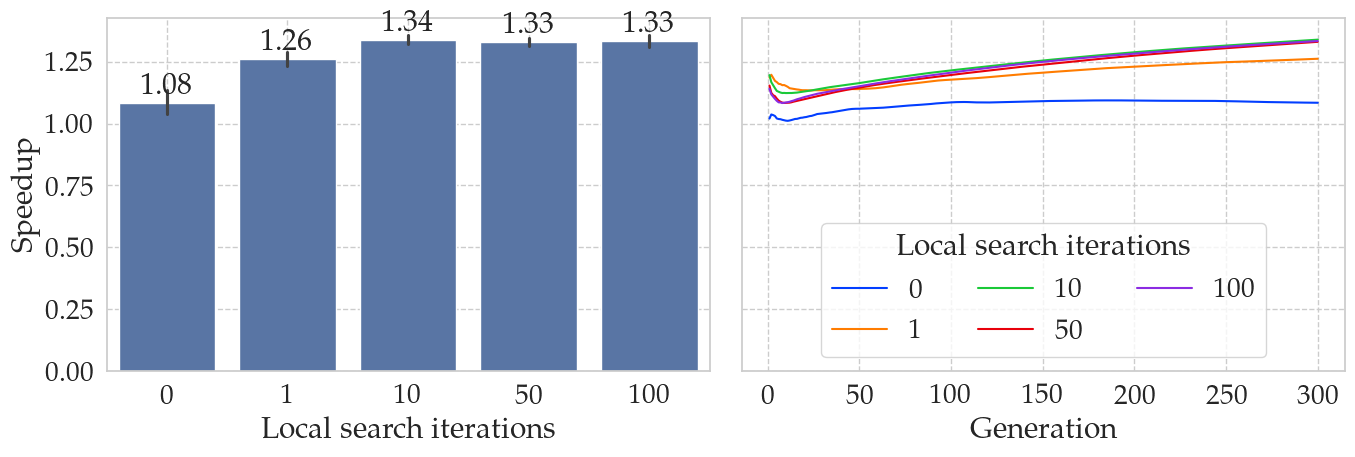

In [5]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(14, 5), sharey=True)
sns.barplot(data=f.filter(pl.col('generation') == 300), ax=ax1, x='iterations', y='speedup')
sns.lineplot(data=f, ax=ax2, x='generation', y='speedup', hue='iterations', errorbar=None, estimator='mean', palette='bright')
ax1.set_ylabel('Speedup')
ax1.set_xlabel('Local search iterations')
sns.move_legend(ax2, loc='lower center', ncols=3, title='Local search iterations')
ax2.set_xlabel('Generation')
for c in ax1.containers:
    ax1.bar_label(c, [f'{v:.2f}' for v in c.datavalues])

for ax in [ax1, ax2]:
    ax.grid(True, linestyle='dashed')

fig.tight_layout()
plt.savefig('./speedup.png', bbox_inches='tight', dpi=300)

# Average fitness

In [7]:
import polars as pl
import numpy as np
from pathlib import Path
from itertools import product

import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": "Palatino",
})

sns.set_theme(style='whitegrid', font='Palatino', font_scale=1.8)

In [8]:
# load data
df = pl.read_ipc('./results.feather')

df = df.with_columns(
    avg_fit = (-pl.col('avg_fit')).clip(0, 1),
    best_fit = (-pl.col('best_fit')).clip(0, 1)
)

Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


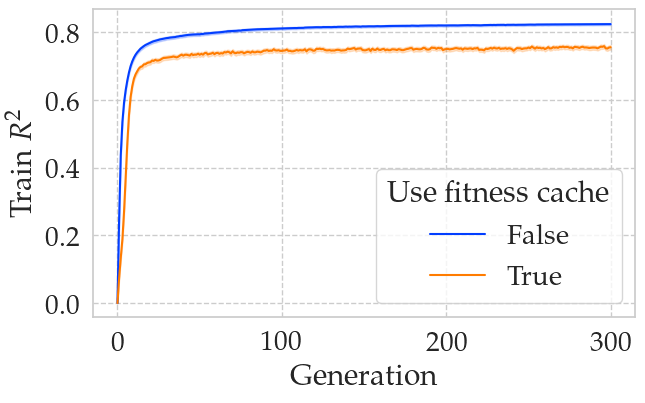

In [9]:
# average fitness overall
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(7,4))
sns.lineplot(data=df, ax=ax, x='generation', y='avg_fit', hue='use_transposition_cache', errorbar=('ci', 95), palette='bright')
ax.grid(True, linestyle='dashed')
ax.set(xlabel='Generation', ylabel='Train $R^2$')
sns.move_legend(ax, loc='lower right', title='Use fitness cache')
plt.savefig('avg_fit.png', bbox_inches='tight', dpi=300)

# Average length

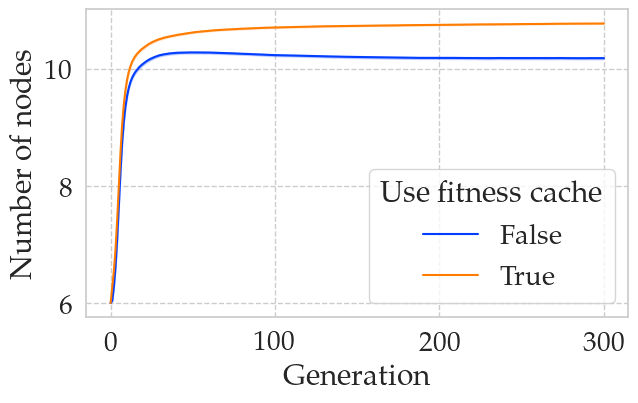

In [11]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(7,4))
sns.lineplot(data=df, ax=ax, x='generation', y='avg_len', hue='use_transposition_cache', errorbar=('ci', 95), palette='bright')
ax.grid(True, linestyle='dashed')
ax.set(xlabel='Generation', ylabel='Number of nodes')
sns.move_legend(ax, loc='lower right', title='Use fitness cache')
plt.savefig('avg_length.png', bbox_inches='tight', dpi=300)

# Cached evals and total evals

In [13]:
import polars as pl
import numpy as np
from pathlib import Path
from itertools import product

import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": "Helvetica",
})

sns.set_theme(style='whitegrid', font='Palatino', font_scale=1.8)

In [14]:
df = pl.read_ipc('./results.feather')

Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


In [15]:
df = df.with_columns(
    elapsed_delta = pl.col('elapsed').diff().fill_null(0).clip(0, np.inf),
    total_eval_delta = pl.col('total_eval').diff().fill_null(0).clip(0, np.inf),
    avg_fit = (-pl.col('avg_fit')).clip(0, 1),
    best_fit = (-pl.col('best_fit')).clip(0, 1)
)

In [16]:
df_cache = df.filter(pl.col('use_transposition_cache') == True)

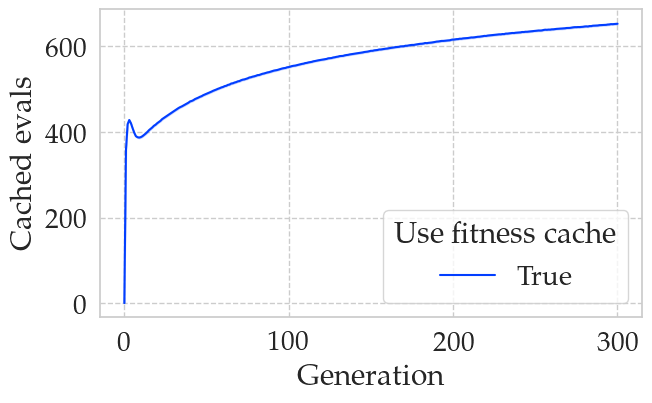

In [18]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(7,4))
sns.lineplot(data=df_cache, ax=ax, x='generation', y='cached_evals', hue='use_transposition_cache', errorbar=('ci', 95), palette='bright')
ax.grid(True, linestyle='dashed')
ax.set(xlabel='Generation', ylabel='Cached evals')
sns.move_legend(ax, loc='lower right', title='Use fitness cache')
plt.savefig('cached_evals.png', bbox_inches='tight', dpi=300)

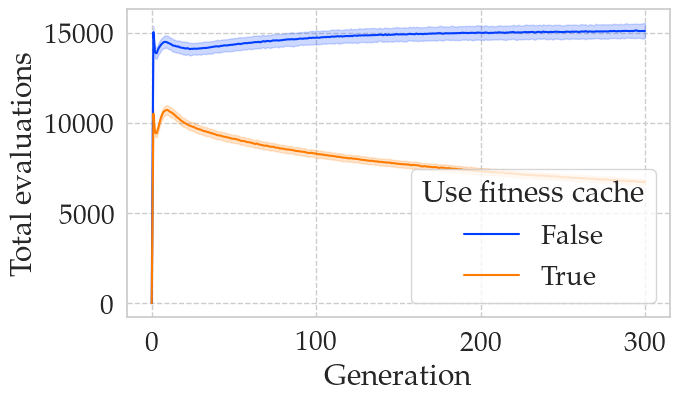

In [19]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(7,4))
sns.lineplot(data=df, ax=ax, x='generation', y='total_eval_delta', hue='use_transposition_cache', errorbar=('ci', 95), palette='bright')
ax.grid(True, linestyle='dashed')
ax.set(xlabel='Generation', ylabel='Total evaluations')
sns.move_legend(ax, loc='lower right', title='Use fitness cache')
plt.savefig('total_evals.png', bbox_inches='tight', dpi=300)